# Práctica evaluación módulo 'Machine Learning y Deep Learning

## 0. Configuración Notebook

### Importación librerías

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

### Definición constantes

In [52]:
DATA_DIR_RAW = '../../data/raw'

In [53]:
DATASET = f'{DATA_DIR_RAW}/dataset_practica_final.csv'
DATASET

'../../data/raw/dataset_practica_final.csv'

### Definición funciones

In [10]:
def compare_scores(model_list, y_test, X_test):
    '''
    muestra un dataframe con índice por modelo y columnas por métrica, valores el valor de la métrica
    '''
    pass

In [5]:
def plot_ROC(model_list, y_test, X_test):
    '''
    saca una figura con un subplot por modelo del ROC
    '''
    pass

In [6]:
def plot_confusion_matrix(model_list, y_test, X_test):
    '''
    saca una figura con un subplot por modelo de la confusion_matrix
    '''
    pass

## 1. Carga y pre-procesamiento de datos

### Carga y copia

In [54]:
df = pd.read_csv(DATASET)
df_limpio = df.copy()

### Inspección

## Variables

| Nombre Variable                  | Descripción                                              |
| -------------------------------- | -------------------------------------------------------- |
| `hotel`                          | Tipo de hotel: City Hotel o Resort Hotel                 |
| `is_canceled`                    | Variable objetivo: 1 si fue cancelado, 0 si no           |
| `lead_time`                      | Días entre la reserva y la fecha de llegada              |
| `arrival_date_year`              | Año de llegada                                           |
| `arrival_date_month`             | Mes de llegada                                           |
| `arrival_date_week_number`       | Número de la semana del año                              |
| `arrival_date_day_of_month`      | Día del mes de llegada                                   |
| `stays_in_weekend_nights`        | Noches de fin de semana reservadas                       |
| `stays_in_week_nights`           | Noches entre semana reservadas                           |
| `adults`                         | Número de adultos                                        |
| `children`                       | Número de niños                                          |
| `babies`                         | Número de bebés                                          |
| `meal`                           | Tipo de comida reservada                                 |
| `country`                        | País de origen del cliente                               |
| `market_segment`                 | Canal de marketing (online, offline, grupos...)          |
| `distribution_channel`           | Canal de distribución (directo, TA/TO...)                |
| `is_repeated_guest`              | 1 si el cliente ha estado anteriormente                  |
| `previous_cancellations`         | Nº de cancelaciones anteriores                           |
| `previous_bookings_not_canceled` | Nº de reservas previas no canceladas                     |
| `reserved_room_type`             | Tipo de habitación reservada                             |
| `assigned_room_type`             | Tipo de habitación asignada                              |
| `booking_changes`                | Nº de cambios en la reserva                              |
| `deposit_type`                   | Tipo de depósito: No Deposit, Refundable, etc.           |
| `agent`                          | ID del agente (puede ser nulo)                           |
| `company`                        | ID de la empresa (puede ser nulo)                        |
| `days_in_waiting_list`           | Días en lista de espera                                  |
| `customer_type`                  | Tipo de cliente: Transient, Group, etc.                  |
| `adr`                            | Average Daily Rate (precio promedio por noche)           |
| `required_car_parking_spaces`    | Plazas de parking solicitadas                            |
| `total_of_special_requests`      | Nº de peticiones especiales                              |
| `reservation_status`             | Estado final de la reserva: Check-Out, Canceled, No-Show |
| `reservation_status_date`        | Fecha en que se actualizó el estado                      |

### *Cosas a ver*:
- si está balanceado
- identificar outlayers
- identificar datos faltantes
- sacar correlaciones
- sacar pca 


In [55]:
df_limpio.info()
# reservation_status y reservation_status_date fuera, en tanto que la primera da información que duplica o es posterior al target y la segunda es un atributo de la primera

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [56]:
#MANUEL
df_limpio.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [65]:
# Tamaño
df_limpio.shape

(87396, 28)

In [58]:
#MANUEL
# mostrar el porcentaje exacto de cancelaciones vs no cancelaciones
porcentajes = df_limpio['is_canceled']. value_counts(normalize=True) * 100
print("Distribución de la variable objetivo (%):")
print(porcentajes)
print('La métrica aquí para observar será F1-Score o AUC-ROC. Accuracy no será una buena métrica porque si el modelo dice siempre "no cancela", acertaría el 63% de las veces sin saber nada ')

Distribución de la variable objetivo (%):
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64
La métrica aquí para observar será F1-Score o AUC-ROC. Accuracy no será una buena métrica porque si el modelo dice siempre "no cancela", acertaría el 63% de las veces sin saber nada 


In [59]:
#MANUEL
# Columnas que tienen valores nulos y cuántos tienen
nulos = df_limpio.isna().sum()
columnas_con_nulos = nulos[nulos > 0]
print("\nColumnas con valores nulos:")
print(columnas_con_nulos)

# Filas duplicadas
print(f"\nFilas duplicadas exactas: {df_limpio.duplicated().sum()}")


Columnas con valores nulos:
children         4
country        488
agent        16340
company     112593
dtype: int64

Filas duplicadas exactas: 31994


In [22]:
print('Eliminaremos company. Demasiados nulos')
print('Con agent, faltan pocos nulos, pero un valor nulo no es un error, significa que el cliente reservó directamente sin usar una agencia. Entonces imputaremos los nulos con el valor 0 para indicar "Reserva Directa".')

Eliminaremos company. Demasiados nulos
Con agent, faltan pocos nulos, pero un valor nulo no es un error, significa que el cliente reservó directamente sin usar una agencia. Entonces imputaremos los nulos con el valor 0 para indicar "Reserva Directa".


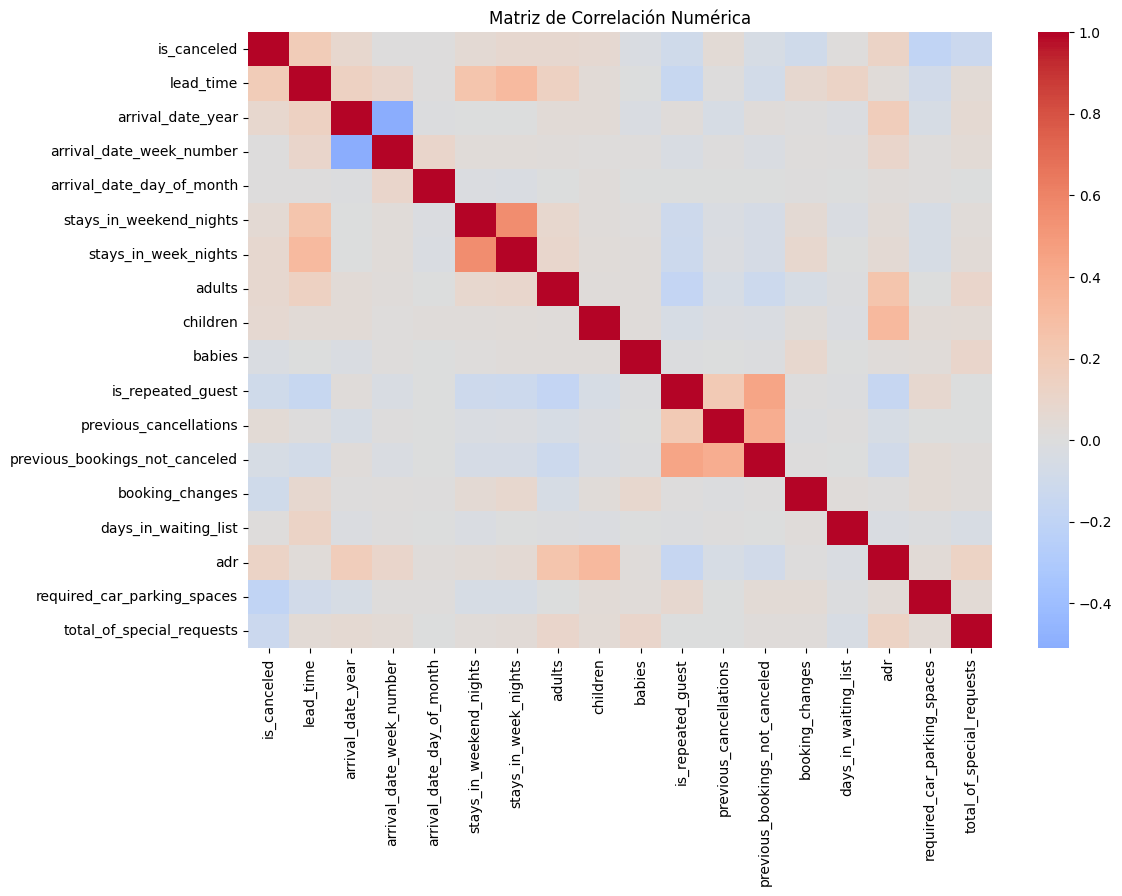

In [60]:
#MANUEL
# Solo columnas numéricas para evitar errores
df_limpio = df_limpio.drop_duplicates()

plt.figure(figsize=(12, 8))
# mapa de calor (sin números para no saturar la vista inicial)
sns.heatmap(df_numerico.corr(), annot=False, cmap='coolwarm', center=0)
plt.title("Matriz de Correlación Numérica")
plt.show()

In [62]:
# Eliminar columnas con demasiados nulos ('company'. 'agent')
# y columnas que generan fuga de datos ('reservation_status', 'reservation_status_date')
columnas_a_borrar = ['company', 'agent', 'reservation_status', 'reservation_status_date']
df_limpio = df_limpio.drop(columns=columnas_a_borrar, errors='ignore')
df_limpio

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,C,C,3,No Deposit,0,Transient,0.00,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,C,C,4,No Deposit,0,Transient,0.00,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,A,C,0,No Deposit,0,Transient,75.00,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,A,A,0,No Deposit,0,Transient,75.00,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,A,A,0,No Deposit,0,Transient,98.00,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,0,A,A,0,No Deposit,0,Transient,96.14,0,0
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,0,E,E,0,No Deposit,0,Transient,225.43,0,2
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,0,D,D,0,No Deposit,0,Transient,157.71,0,4
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,0,A,A,0,No Deposit,0,Transient,104.40,0,0


In [67]:
# Imputar los pocos nulos restantes en 'children' y 'country'
df_limpio['children'] = df_limpio['children'].fillna(0)
df_limpio['country'] = df_limpio['country'].fillna(df_limpio['country'].mode()[0])

In [68]:
print(f"Tamaño tras limpieza base: {df_limpio.shape}")

Tamaño tras limpieza base: (87396, 28)


In [69]:
# Eliminaciónd e outliers (Claudi)
# Identificamos variables numéricas continuas (excluimos categóricas y binarias como is_canceled)
columnas_excluir = df_limpio.select_dtypes(include=['object']).columns.tolist() + ['is_canceled', 'is_repeated_guest']
numeric_fields = [c for c in df_limpio.columns if c not in columnas_excluir]

In [70]:
# Creamos una máscara booleana para quedarnos solo con valores dentro de 5 desviaciones típicas
mascara_outliers = pd.Series(True, index=df_limpio.index)
filter_val = 5

for c in numeric_fields:
    z_scores = abs(df_limpio[c] - df_limpio[c].mean()) / df_limpio[c].std()
    mascara_outliers &= (z_scores < filter_val)

# Aplicamos el filtro al dataframe
df_limpio = df_limpio[mascara_outliers]
print(f"Tamaño tras eliminar outliers extremos: {df_limpio.shape}")

Tamaño tras eliminar outliers extremos: (84360, 28)


In [73]:
# Separación de pistas (X) y Objetivo (y)
X = df_limpio.drop(columns=['is_canceled'])
y = df_limpio['is_canceled']

In [74]:
# Transformación matemática
variables_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
variables_categoricas = X.select_dtypes(include=['object']).columns.tolist()

In [75]:
# Se construye el motor: Estandariza números y hace One-Hot del texto
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_numericas),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), variables_categoricas)
    ],
    remainder='passthrough' # Mantiene tal cual variables como is_repeated_guest (que ya es 0 o 1)
)

In [76]:
# Se aplica la transformación
X_procesado = preprocesador.fit_transform(X)

In [77]:
print(f"Dimensiones de X procesado listo para entrenar: {X_procesado.shape}")

Dimensiones de X procesado listo para entrenar: (84360, 245)


In [ ]:
# Aquí ya habríamos superado la parte del preprocesamiento. Tenemos datos sin nulos, sin duplicados,
# sin outliers absurdos, escalados al centro 0 y con las categorías correctamente separadas en columnas de 0 y 1.

In [79]:
# Para ver las categorías separadas en columnas de 0 y 1...
# Extraer los nuevos nombres de las columnas generadas por el transformador
nombres_columnas = preprocesador.get_feature_names_out()

# Convertir la matriz de vuelta a un DataFrame de Pandas
df_procesado_visual = pd.DataFrame(X_procesado, columns=nombres_columnas)

# Forzar a Pandas a que nos muestre TODAS las columnas sin esconderlas con puntos suspensivos
pd.set_option('display.max_columns', None)

# Mostrar las primeras 5 filas
display(df_procesado_visual.head())

,num__lead_time,num__arrival_date_year,num__arrival_date_week_number,num__arrival_date_day_of_month,num__stays_in_weekend_nights,num__stays_in_week_nights,num__adults,num__children,num__babies,num__is_repeated_guest,num__previous_cancellations,num__previous_bookings_not_canceled,num__booking_changes,num__days_in_waiting_list,num__adr,num__required_car_parking_spaces,num__total_of_special_requests,cat__hotel_Resort Hotel,cat__arrival_date_month_August,cat__arrival_date_month_December,cat__arrival_date_month_February,cat__arrival_date_month_January,cat__arrival_date_month_July,cat__arrival_date_month_June,cat__arrival_date_month_March,cat__arrival_date_month_May,cat__arrival_date_month_November,cat__arrival_date_month_October,cat__arrival_date_month_September,cat__meal_FB,cat__meal_HB,cat__meal_SC,cat__meal_Undefined,cat__country_AGO,cat__country_AIA,cat__country_ALB,cat__country_AND,cat__country_ARE,cat__country_ARG,cat__country_ARM,cat__country_ASM,cat__country_ATA,cat__country_ATF,cat__country_AUS,cat__country_AUT,cat__country_AZE,cat__country_BDI,cat__country_BEL,cat__country_BEN,cat__country_BFA,cat__country_BGD,cat__country_BGR,cat__country_BHR,cat__country_BHS,cat__country_BIH,cat__country_BLR,cat__country_BOL,cat__country_BRA,cat__country_BRB,cat__country_BWA,cat__country_CAF,cat__country_CHE,cat__country_CHL,cat__country_CHN,cat__country_CIV,cat__country_CMR,cat__country_CN,cat__country_COL,cat__country_COM,cat__country_CPV,cat__country_CRI,cat__country_CUB,cat__country_CYM,cat__country_CYP,cat__country_CZE,cat__country_DEU,cat__country_DJI,cat__country_DMA,cat__country_DNK,cat__country_DOM,cat__country_DZA,cat__country_ECU,cat__country_EGY,cat__country_ESP,cat__country_EST,cat__country_ETH,cat__country_FIN,cat__country_FJI,cat__country_FRA,cat__country_FRO,cat__country_GAB,cat__country_GBR,cat__country_GEO,cat__country_GGY,cat__country_GHA,cat__country_GIB,cat__country_GLP,cat__country_GNB,cat__country_GRC,cat__country_GTM,cat__country_GUY,cat__country_HKG,cat__country_HND,cat__country_HRV,cat__country_HUN,cat__country_IDN,cat__country_IMN,cat__country_IND,cat__country_IRL,cat__country_IRN,cat__country_IRQ,cat__country_ISL,cat__country_ISR,cat__country_ITA,cat__country_JAM,cat__country_JEY,cat__country_JOR,cat__country_JPN,cat__country_KAZ,cat__country_KEN,cat__country_KHM,cat__country_KIR,cat__country_KNA,cat__country_KOR,cat__country_KWT,cat__country_LAO,cat__country_LBN,cat__country_LBY,cat__country_LCA,cat__country_LIE,cat__country_LKA,cat__country_LTU,cat__country_LUX,cat__country_LVA,cat__country_MAC,cat__country_MAR,cat__country_MCO,cat__country_MDG,cat__country_MDV,cat__country_MEX,cat__country_MKD,cat__country_MLI,cat__country_MLT,cat__country_MMR,cat__country_MNE,cat__country_MOZ,cat__country_MRT,cat__country_MUS,cat__country_MWI,cat__country_MYS,cat__country_MYT,cat__country_NAM,cat__country_NCL,cat__country_NGA,cat__country_NIC,cat__country_NLD,cat__country_NOR,cat__country_NPL,cat__country_NZL,cat__country_OMN,cat__country_PAK,cat__country_PAN,cat__country_PER,cat__country_PHL,cat__country_PLW,cat__country_POL,cat__country_PRI,cat__country_PRT,cat__country_PRY,cat__country_PYF,cat__country_QAT,cat__country_ROU,cat__country_RUS,cat__country_RWA,cat__country_SAU,cat__country_SDN,cat__country_SEN,cat__country_SGP,cat__country_SLE,cat__country_SLV,cat__country_SMR,cat__country_SRB,cat__country_STP,cat__country_SUR,cat__country_SVK,cat__country_SVN,cat__country_SWE,cat__country_SYC,cat__country_SYR,cat__country_TGO,cat__country_THA,cat__country_TJK,cat__country_TMP,cat__country_TUN,cat__country_TUR,cat__country_TWN,cat__country_TZA,cat__country_UGA,cat__country_UKR,cat__country_UMI,cat__country_URY,cat__country_USA,cat__country_UZB,cat__country_VEN,cat__country_VGB,cat__country_VNM,cat__country_ZAF,cat__country_ZMB,cat__country_ZWE,cat__market_segment_Complementary,cat__market_segment_Corporate,cat__market_segment_Direct,cat__market_segment_Groups,cat__market_segment_Offline TA/TO,cat__market_segment_Online TA,

## 2. Entrenamiento (incluye selección de hiperparámetros)

### 2.1 Logistic Regression

### 2.2 DecisionTree

### 2.3 Random Forest

### 2.4 XGBoost

### 2.5 Multilayer Neural Network

## 3. Comparativa Modelos